In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import time
import gc

import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.utils.tensorboard import SummaryWriter
import torchvision.transforms.functional as VF
from torch.autograd.graph import saved_tensors_hooks

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

device = 'cuda'
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.8.0+cu128


## Functions

In [2]:
def calculate_training_memory(model, dataset, criterion, batch_size=4, device="cuda"):
    model.to(device)
    model.zero_grad()
    model.train()

    total_params=sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    dataLoader = DataLoader(
        dataset=dataset,
        batch_size=batch_size)

    input, target = next(iter(dataLoader))
    input, target = input.to(device), target.to(device)

    seen_ptrs = set([p.data_ptr() for p in model.parameters()]) # To avoid storing model parameters
    saved = []

    def pack_hook(t):
        # Runs during forward when autograd saves a tensor
        tensor_dict = {
            "shape": t.shape,
            "dtype": t.dtype,
            "device": t.device,
            "requires_grad": t.requires_grad,
            "numel": t.numel(),
            "element_size": t.element_size(),
            "memory" : t.numel() * t.element_size(),
            "data_ptr": t.data_ptr()
        }
        if not t.data_ptr() in seen_ptrs:
            saved.append(tensor_dict)
            seen_ptrs.add(t.data_ptr())
        return t

    def unpack_hook(t):
        # Runs during backward when autograd unpacks it
        return t

    with saved_tensors_hooks(pack_hook, unpack_hook):
        logits = model(input)
        loss = criterion(logits, target)
        loss.backward()

    activation_memory = sum(s["memory"] for s in saved)
    result = {
        "number_of_params": total_params,
        "memory_activations_per_example": activation_memory / batch_size,
        "memory_params": total_params * 4,
        "memory_grad": total_params * 4,
        "memory_adam": total_params * 8,
        "memory_total": activation_memory + total_params * 16,
        "unit": "B"
    }
    return result

def calculate_throughput(model, dataset, optimizer, criterion, batch_size, device, max_time_s):
    model.train()
    optimizer.zero_grad()
    data_loader = DataLoader(
        dataset = dataset,
        batch_size = batch_size)

    
    total_obs = 0
    start_time = time.time()
    while True:
        for i, (input, target) in enumerate(data_loader):
            input, target = input.to(device), target.to(device)
            logits = model(input)
            loss = criterion(logits, target)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            total_obs += len(input)
            if time.time() - start_time > max_time_s:
                throughput = total_obs / (time.time() - start_time)
                return throughput

def cuda_free_memory():
    gc.collect()
    torch.cuda.synchronize()     # wait for all kernels to finish
    torch.cuda.empty_cache()     # release cached blocks back to the driver
    torch.cuda.ipc_collect()     # free inter-process memory handles            

def print_cuda_memory():
    if not torch.cuda.is_available():
        print("CUDA not available")
        return

    allocated = torch.cuda.memory_allocated() / 1024**2
    reserved  = torch.cuda.memory_reserved() / 1024**2
    max_alloc = torch.cuda.max_memory_allocated() / 1024**2
    max_res   = torch.cuda.max_memory_reserved() / 1024**2

    print(f"Currently allocated: {allocated:.2f} MB")
    print(f"Currently reserved : {reserved:.2f} MB")
    print(f"Max allocated      : {max_alloc:.2f} MB")
    print(f"Max reserved       : {max_res:.2f} MB")    

def list_cuda_objects():
    """List all live Python objects that hold CUDA memory."""
    cuda_objects = []
    for obj in gc.get_objects():
        try:
            if torch.is_tensor(obj) and obj.is_cuda:
                cuda_objects.append(obj)
            elif hasattr(obj, "data") and torch.is_tensor(obj.data) and obj.data.is_cuda:
                cuda_objects.append(obj)
        except Exception:
            pass  # ignore uninspectable objects
    return cuda_objects

def check_is_batch_feasible(model, dataset, optimizer, criterion, batch_size, device):
    try:
        model.train()
        optimizer.zero_grad()
        data_loader = DataLoader(
            dataset = dataset,
            batch_size = batch_size)
    
        for i, (input, target) in enumerate(data_loader):
            input, target = input.to(device), target.to(device)
            logits = model(input)
            loss = criterion(logits, target)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
    except torch.cuda.OutOfMemoryError:
        return False
    return True

## Dataset

In [3]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./DATA",
    train=True,
    download=True,
    transform=transform)

test_dataset = datasets.MNIST(
    root="./DATA",
    train=False,
    download=True,
    transform=transforms.ToTensor())    

## Model class

In [4]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 16384)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(16384, 8192)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(8192, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)        
        return x

In [5]:
print_cuda_memory()

model = SimpleNN().to(device)
optimizer = optim.AdamW(
    params=model.parameters(),
    lr=0.001,
    weight_decay=0.01
)
criterion = nn.CrossEntropyLoss()

print_cuda_memory()

del model, optimizer, criterion
cuda_free_memory()

print_cuda_memory()

print(list_cuda_objects())

Currently allocated: 0.00 MB
Currently reserved : 0.00 MB
Max allocated      : 0.00 MB
Max reserved       : 0.00 MB
Currently allocated: 561.41 MB
Currently reserved : 582.00 MB
Max allocated      : 561.41 MB
Max reserved       : 582.00 MB
Currently allocated: 0.00 MB
Currently reserved : 0.00 MB
Max allocated      : 561.41 MB
Max reserved       : 582.00 MB
[]


/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1125: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)
/tmp/ipykernel_23257/532073979.py:107: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  elif hasattr(obj, "data") and torch.is_tensor(obj.data) and obj.data.is_cuda:
/usr/local/lib/python3.12/dist-packages/tensorboard/data/server_ingester.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Basic model objects

In [6]:
model = SimpleNN().to(device)
optimizer = optim.AdamW(
    params=model.parameters(),
    lr=0.001,
    weight_decay=0.01
)
criterion = nn.CrossEntropyLoss()
#scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)

## Calculate max batch size

In [6]:
min_batch = 1
max_batch = len(train_dataset)

while max_batch - min_batch > 1:
    current_batch = (max_batch + min_batch) // 2

    model = SimpleNN().to(device)
    optimizer = optim.AdamW(
        params=model.parameters(),
        lr=0.001,
        weight_decay=0.01
    )
    criterion = nn.CrossEntropyLoss()
    current_batch_result = check_is_batch_feasible(model, train_dataset, optimizer, criterion, current_batch, 'cuda')

    print(f"Current batch = {current_batch} Result: {current_batch_result}")

    if current_batch_result:
        min_batch = current_batch
    else:
        max_batch = current_batch
    
    del model, optimizer, criterion
    cuda_free_memory()
    
    print_cuda_memory()
    
    for c in list_cuda_objects():
        print(c.shape)
print(f"Max batch that works: {min_batch}")

Current batch = 30000 Result: False
Currently allocated: 16.25 MB
Currently reserved : 60.00 MB
Max allocated      : 7111.41 MB
Max reserved       : 7142.00 MB


/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1125: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)
/tmp/ipykernel_23257/532073979.py:107: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  elif hasattr(obj, "data") and torch.is_tensor(obj.data) and obj.data.is_cuda:


Current batch = 15000 Result: True
Currently allocated: 16.25 MB
Currently reserved : 60.00 MB
Max allocated      : 7111.41 MB
Max reserved       : 7142.00 MB
Current batch = 22500 Result: True
Currently allocated: 16.25 MB
Currently reserved : 60.00 MB
Max allocated      : 7111.41 MB
Max reserved       : 7626.00 MB
Current batch = 26250 Result: True
Currently allocated: 16.25 MB
Currently reserved : 60.00 MB
Max allocated      : 7214.40 MB
Max reserved       : 7626.00 MB
Current batch = 28125 Result: False
Currently allocated: 16.25 MB
Currently reserved : 60.00 MB
Max allocated      : 7214.40 MB
Max reserved       : 7626.00 MB
Current batch = 27187 Result: True
Currently allocated: 16.25 MB
Currently reserved : 60.00 MB
Max allocated      : 7392.93 MB
Max reserved       : 7626.00 MB
Current batch = 27656 Result: True
Currently allocated: 16.25 MB
Currently reserved : 60.00 MB
Max allocated      : 7482.29 MB
Max reserved       : 7626.00 MB
Current batch = 27890 Result: True
Currently 

In [ ]:
model = SimpleNN().to(device)
optimizer = optim.AdamW(
        params=model.parameters(),
        lr=0.001,
        weight_decay=10
)
criterion = nn.CrossEntropyLoss()

for i in range(12, 30, 1):
    batch_size = 1024 * (i + 1)
    dataLoader = DataLoader(
        dataset=train_dataset,
        batch_size=batch_size)
    
    input, target = next(iter(dataLoader))
    input, target = input.to(device), target.to(device)
    
    model.train()
    model.zero_grad()
    
    logits = model(input)
    loss = criterion(logits, target)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad(set_to_none=True)
    print(batch_size)

    del input, target, logits, loss
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

## Calculate max throughput

In [31]:
batch_size_to_test = [1, 16, 64, 128, 256, 512, 1024, 1536, 2048, 3072, 4096]
throughput_results = {
    x:calculat_throughput(
        model = model,
        dataset = train_dataset,
        optimizer = optimizer,
        criterion = criterion,
        batch_size = x,
        device = 'cuda', 
        max_time_s = 5) for x in batch_size_to_test
}

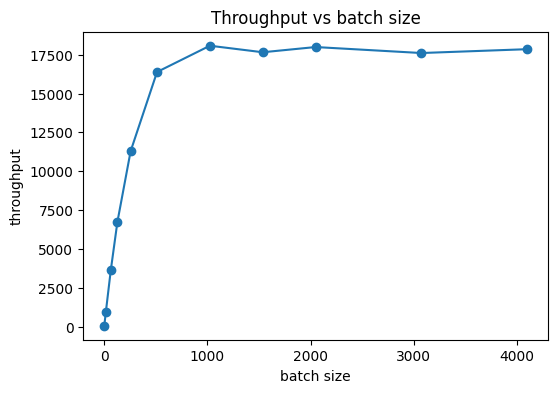

In [37]:
x = list(throughput_results.keys())
y = list(throughput_results.values())
plt.figure(figsize=(6,4))
plt.plot(x, y, marker='o', linestyle='-')
plt.xlabel('batch size')
plt.ylabel('throughput')
plt.title('Throughput vs batch size')
plt.show()

In [ ]:
model = SimpleNN().to(device)
optimizer = optim.AdamW(
        params=model.parameters(),
        lr=0.001,
        weight_decay=10
)
criterion = nn.CrossEntropyLoss()

for i in range(12, 30, 1):
    batch_size = 1024 * (i + 1)
    dataLoader = DataLoader(
        dataset=train_dataset,
        batch_size=batch_size)
    
    input, target = next(iter(dataLoader))
    input, target = input.to(device), target.to(device)
    
    model.train()
    model.zero_grad()
    
    logits = model(input)
    loss = criterion(logits, target)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad(set_to_none=True)
    print(batch_size)

    del input, target, logits, loss
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

In [ ]:




batch_size = 20000
device = "cuda"

criterion = nn.CrossEntropyLoss()
result = calculate_training_memory(
    model = model,
    dataset = train_dataset,
    criterion = criterion,
    batch_size = batch_size,
    device = device)
print(result)

In [11]:
def test_model(model, dataloader, criterion):
    model.eval()
    running_loss_test = 0.0
    n_obs_test = 0
    for data, target in dataloader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        loss = criterion(output, target)
        running_loss_test += loss.item() * len(data)
        n_obs_test += len(data)
    epoch_loss_test = running_loss_test / n_obs_test
    return epoch_loss_test

In [ ]:
def gradient_noise_scale(model: nn.Module, dataset: torch.utils.data.dataset.Dataset, criterion: torch.nn.modules.module.Module, n: int, k: int):
    model.eval()
    data_loader=DataLoader(
        dataset=dataset,
        batch_size=k,
        shuffle=True,
        num_workers=0,
        pin_memory=False,
        persistent_workers=False,
        drop_last=True)
    grads = []
    data_iter = iter(data_loader)
    for i in range(n):
        try:
            data, label = next(data_iter)
        except StopIteration:
            data_iter = iter(data_loader)
            data, label = next(data_iter) 
        model.zero_grad()
        data, label = data.to(device), label.to(device)
        output = model(data)
        loss = criterion(output, label)
        loss.backward()
        grad_vector = torch.cat([p.grad.detach().flatten() for p in model.parameters()])
        grads.append(grad_vector)
    G = torch.stack(grads)
    grad_var = torch.var(G, dim=0)
    grad_mean = torch.mean(G, dim=0)
    S = grad_var.mean() / grad_mean.pow(2).mean()
    return S.item()
    

In [16]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=512,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    drop_last=True)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=512,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    drop_last=False)

In [17]:
n = 16
k = 256


exp_folder = f'runs/model_{int(time.time())}'
writer_train = SummaryWriter(f"{exp_folder}/train")
writer_valid = SummaryWriter(f"{exp_folder}/valid")
global_step = 0
beta1, beta2 = optimizer.param_groups[0]["betas"]
base_lr = optimizer.param_groups[0]["lr"]
eps = optimizer.param_groups[0]["eps"]
for epoch in range(1):
    running_loss = 0.0
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        running_loss += loss.item()

        # Log Params Batch
        total_param_norm = 0.0
        total_param_count = 0.0
        total_grad_norm = 0.0
        for name, param in model.named_parameters():
            if param.requires_grad:
                if "bias" in name:
                    short_name = name[:-5]
                    group_name = "Bias"
                else:
                    short_name = name[:-7]
                    group_name = "Weight"
                
                writer_train.add_scalar(f"{group_name}_param_norm_scaled/{short_name}", param.data.norm(2) / (param.data.numel() ** 0.5), global_step) 
                writer_train.add_scalar(f"{group_name}_gradient_norm/{short_name}", param.grad.data.norm(2), global_step) 

                total_param_norm += param.data.norm(2) ** 2
                total_param_count += param.data.numel()
                total_grad_norm += param.grad.data.norm(2) ** 2

                if global_step>0:
                    step = optimizer.state[param]['step'] 
                    m_t = optimizer.state[param]['exp_avg'] / (1 - beta1 ** step)
                    v_t = optimizer.state[param]['exp_avg_sq'] / (1 - beta2 ** step)
                    effective_update = base_lr * m_t / (v_t ** 0.5 + eps)
                    writer_train.add_scalar(f"{group_name}_update_ratio/{short_name}", effective_update.abs().mean() / param.detach().abs().mean(), global_step)
        
        writer_train.add_scalar(f"Total_norm/Param_scaled", (total_param_norm / total_param_count) ** 0.5, global_step) 
        writer_train.add_scalar(f"Total_norm/Gradient", total_grad_norm ** 0.5, global_step)
        writer_train.add_scalar("Loss/batch", loss.item(), global_step)
        
        global_step += 1
        clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step() 

    # Log Params Epoch
    for name, param in model.named_parameters():
        if param.requires_grad:
            if "bias" in name:
                short_name = name[:-5]
                group_name = "Bias"
            else:
                short_name = name[:-7]
                group_name = "Weight"
        writer_train.add_histogram(f"{group_name}_param/{short_name}", param.data.cpu(), epoch)
        writer_train.add_histogram(f"{group_name}_gradient/{short_name}", param.grad.data.cpu(), epoch)
    loss_train_epoch = running_loss / len(train_loader)
    writer_train.add_scalar("Loss/epoch", loss_train_epoch, epoch)

    loss_valid_epoch = test_model(model = model, dataloader = test_loader, criterion = criterion)
    writer_valid.add_scalar("Loss/epoch", loss_valid_epoch, epoch)

    S = gradient_noise_scale(
        model = model,
        dataset = train_dataset,
        criterion = criterion,
        n = n,
        k = k)
    writer_train.add_scalar("Optimal_batch", int(S*k), epoch)

    writer_train.add_scalar("LR", scheduler.get_last_lr()[0], epoch)
    scheduler.step()
    
writer_train.close()
writer_valid.close()

NameError: name 'test_model' is not defined

In [ ]:
i = 1
data = model.fc1.weight.detach().cpu()[i, :].view(28, 28).cpu().numpy()
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
img = plt.imshow(data, cmap='viridis', aspect='auto')
plt.colorbar(img, label="Weight value")
plt.show()

In [ ]:
(model.fc1.weight.detach().abs() < 0.01).to(torch.float32).mean()

In [ ]:
??optim.AdamW